# 🩺 Diabetic Retinopathy Classification Using Deep Learning

## 📌 Project Overview

Diabetic Retinopathy (DR) is one of the leading causes of vision impairment and blindness among people with diabetes. It occurs when prolonged high blood sugar damages the tiny blood vessels in the retina, leading to progressive vision loss if left untreated.

Early detection of diabetic retinopathy is crucial because timely treatment can significantly reduce the risk of permanent blindness. However, manual diagnosis requires experienced ophthalmologists and can be both time-consuming and expensive.

In this project, we develop an automated deep learning system capable of classifying retinal fundus images into different stages of diabetic retinopathy. The objective is to assist medical professionals by providing a fast, reliable, and accurate computer-aided diagnosis system.

---

# 📂 Dataset

The dataset used in this project is the **APTOS 2019 Blindness Detection Dataset**, which contains color retinal fundus images collected from diabetic patients.

Each image is labeled according to the severity of diabetic retinopathy using one of five classes.

| Label | Class | Description |
|--------|------------------|--------------------------------------|
| 0 | No_DR | No signs of diabetic retinopathy |
| 1 | Mild | Mild non-proliferative diabetic retinopathy |
| 2 | Moderate | Moderate non-proliferative diabetic retinopathy |
| 3 | Severe | Severe non-proliferative diabetic retinopathy |
| 4 | Proliferative_DR | Advanced proliferative diabetic retinopathy |

The dataset is highly imbalanced, making the classification task more challenging and requiring additional techniques such as transfer learning, class weighting, and focal loss.

---

# 🎯 Project Objectives

The primary objectives of this notebook are:

- Build an automated diabetic retinopathy classification model.
- Apply transfer learning using EfficientNetB0 pretrained on ImageNet.
- Fine-tune the pretrained network to improve performance.
- Investigate the impact of class imbalance.
- Evaluate multiple optimization techniques including:
  - Data Augmentation
  - Fine-Tuning
  - Class Weighting
  - Focal Loss
- Analyze the model using confusion matrices and classification metrics.
- Compare different training strategies to identify the most effective approach.

---

# 🏗️ Deep Learning Pipeline

The complete workflow of this notebook consists of the following stages:

1. Import required libraries
2. Load the dataset
3. Explore and visualize the data
4. Split the dataset into training, validation, and testing sets
5. Apply data augmentation
6. Build the EfficientNetB0 transfer learning model
7. Train the classification head
8. Fine-tune the pretrained backbone
9. Handle class imbalance using Class Weights
10. Improve minority class learning using Focal Loss
11. Evaluate the trained model
12. Analyze the experimental results

---

# 📈 Evaluation Metrics

Model performance is evaluated using multiple metrics rather than relying solely on accuracy.

The following evaluation metrics are reported:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

Since this is a medical image classification problem with imbalanced classes, macro-averaged metrics and class-wise performance are carefully analyzed in addition to overall accuracy.

---

# 💡 Expected Outcome

By the end of this notebook, we aim to develop a robust deep learning model capable of accurately classifying diabetic retinopathy stages from retinal fundus images while investigating different optimization techniques to improve the recognition of minority disease classes.

# 📚 1. Import Required Libraries

In this section, all the required libraries are imported for data manipulation, visualization, image preprocessing, model development, and performance evaluation.

The imported libraries cover the following tasks:

- **NumPy & Pandas** for numerical operations and dataset handling.
- **Matplotlib & Seaborn** for data visualization.
- **OpenCV** for image processing.
- **TensorFlow / Keras** for building and training deep learning models.
- **Scikit-learn** for dataset splitting, evaluation metrics, and class weighting.
- **EfficientNetB0** as the transfer learning backbone pretrained on ImageNet.

Using these libraries provides a complete deep learning pipeline from data preparation to model evaluation.

In [1]:
import numpy as np
import pandas as pd
import random
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt             
import cv2                                 
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split 
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm
import warnings 
warnings.filterwarnings("ignore")

# 📂 2. Load and Explore the Dataset

The diabetic retinopathy dataset is loaded into a Pandas DataFrame containing the image paths and their corresponding disease labels.

Before training, the dataset is explored to:

- Verify that all images are correctly loaded.
- Inspect the distribution of each diabetic retinopathy stage.
- Detect any missing or duplicated samples.
- Understand the class imbalance problem.

This initial exploration helps determine whether additional preprocessing techniques such as class weighting or focal loss are required.

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
IMAGE_SHAPE = (IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS)
LOSS_OPTIMIZER = 'categorical_crossentropy'
METRICS='accuracy'

In [3]:
class_names = os.listdir('/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/colored_images')
class_names.reverse()
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

class_names, class_names_label

(['Severe', 'No_DR', 'Moderate', 'Proliferate_DR', 'Mild'],
 {'Severe': 0, 'No_DR': 1, 'Moderate': 2, 'Proliferate_DR': 3, 'Mild': 4})

In [4]:
path = '/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/colored_images/'

def load_data():
    
    df_all = pd.DataFrame(columns = ['image_path', 'label'])
    
    # Iterate through training and test sets
    # for split in splits:
        
    images_path = []
    label = []
    
    # print("Loading {}".format(split))
    
    # Iterate through each folder corresponding to a category
    root = path
    for folder in os.listdir(root):
        
        # Iterate through each image in our folder
        
        for file in tqdm(os.listdir(os.path.join(root, folder))):
            images_path.append(os.path.join(os.path.join(root, folder), file))
            label.append(folder)  
    
    df_conc = pd.DataFrame({
            "image_path": images_path,
            "label": label
        })
    df_all = pd.concat([df_conc, df_all], ignore_index=True)

    return df_all

In [5]:
df_all = load_data()
df_all

100%|██████████| 193/193 [00:00<00:00, 288901.02it/s]


,image_path,label
0,/kaggle/input/datasets/sovitrath/diabetic-reti...,Mild
1,/kaggle/input/datasets/sovitrath/diabetic-reti...,Mild
2,/kaggle/input/datasets/sovitrath/diabetic-reti...,Mild
3,/kaggle/input/datasets/sovitrath/diabetic-reti...,Mild
4,/kaggle/input/datasets/sovitrath/diabetic-reti...,Mild
...,...,...
3657,/kaggle/input/datasets/sovitrath/diabetic-reti...,Severe
3658,/kaggle/input/datasets/sovitrath/diabetic-reti...,Severe
3659,/kaggle/input/datasets/sovitrath/diabetic-reti...,Severe
3660,/kaggle/input/datasets/sovitrath/diabetic-reti...,Severe


# 📊 3. Dataset Visualization

To better understand the dataset, several sample images from each diabetic retinopathy class are displayed.

Visualizing the dataset allows us to:

- Verify image quality.
- Observe visual differences between disease stages.
- Gain intuition about the complexity of the classification task.

Medical image visualization is an essential step before training any deep learning model.

In [6]:
df_all['label'].value_counts()

label
No_DR             1805
Moderate           999
Mild               370
Proliferate_DR     295
Severe             193
Name: count, dtype: int64

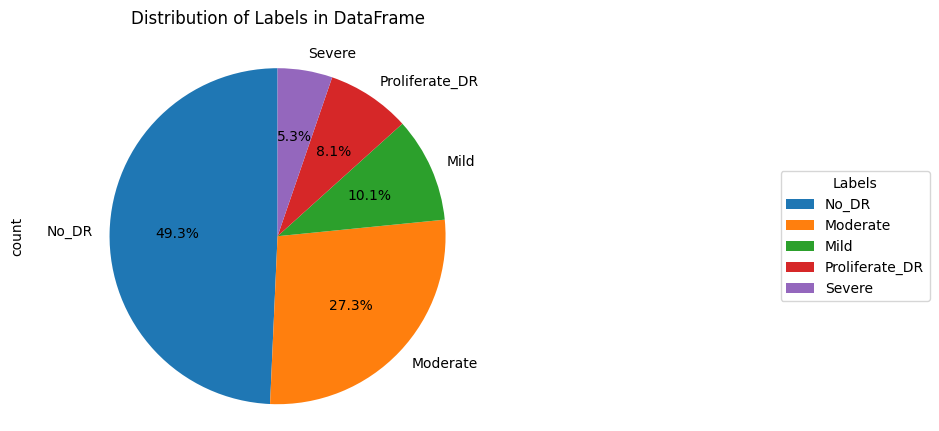

In [7]:
# Get the value counts
counts = df_all['label'].value_counts()

# Plot pie chart
counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, labels=counts.index)
plt.axis('equal')
plt.title('Distribution of Labels in DataFrame', pad=20)

# Cleanly position the legend just outside the right edge of the chart
plt.legend(counts.index, title="Labels", loc="center left", bbox_to_anchor=(1.5, 0.5))

# CRITICAL: Use bbox_inches='tight' during savefig so the external legend isn't clipped
plt.savefig('train_df_pie_chart.png', bbox_inches='tight')

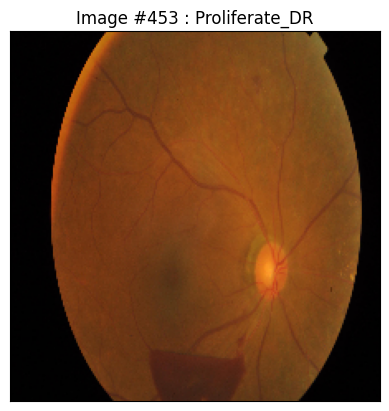

In [8]:
def display_random_image(class_names, images, labels):
    """
        Display a random image from the images array and its correspond label from the labels array.
    """
    
    images = images.to_numpy()
    labels = labels.to_numpy()
    
    index = np.random.randint(len(images))
    plt.figure()
    
    img = cv2.imread(images[index])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE) 
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title(f"Image #{index} : {labels[index]}")
    plt.show()

display_random_image(class_names, df_all['image_path'], df_all['label'])

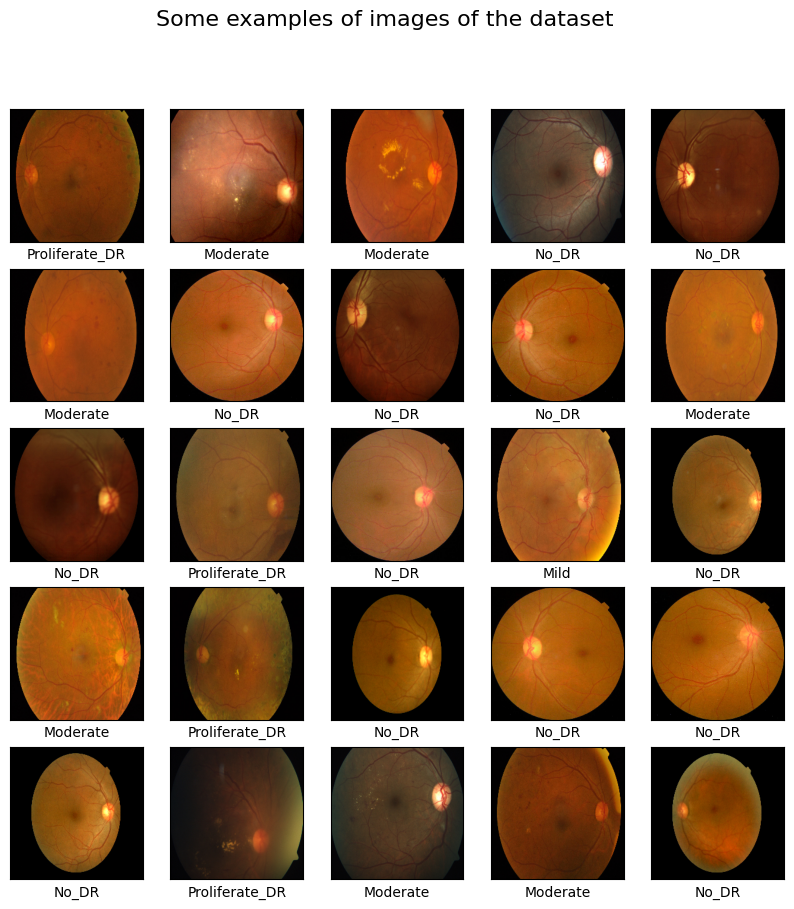

In [9]:
def display_examples(class_names, images, labels):
    """
        Display 25 random images from the images array with its corresponding labels
    """
    
    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        index = i + random.choice(range(images.shape[0])) - 25
        img = cv2.imread(images[index])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMAGE_SIZE)
        plt.imshow(img)
        plt.xlabel(labels[index])
    plt.show()

display_examples(class_names, df_all['image_path'], df_all['label'])

# ✂️ 4. Dataset Splitting

The dataset is divided into three subsets:

- **Training Set** – used for learning model parameters.
- **Validation Set** – used to monitor model performance during training.
- **Testing Set** – used only for the final evaluation.

A **stratified split** is applied to preserve the original class distribution across all subsets.

This ensures that each diabetic retinopathy stage is fairly represented during training and evaluation, resulting in a more reliable performance assessment.

In [10]:
df_train, df_test = train_test_split(
    df_all,
    test_size=0.1,
    stratify=df_all["label"],
    random_state=42
)

df_train, df_val = train_test_split(
    df_train,
    test_size=0.1,
    stratify=df_train["label"],
    random_state=42
)

print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))

Train size: 2965
Val size: 330
Test size: 367


# 🔄 5. Data Augmentation

Since deep learning models require a large variety of training samples, data augmentation is applied to increase the diversity of the training images without collecting additional data.

The following augmentation techniques are used:

- Small random rotations
- Width and height shifts
- Zooming
- Shearing
- ImageNet preprocessing using EfficientNet preprocessing function

Validation and testing images are **not augmented** to ensure unbiased model evaluation.

Data augmentation improves the model's ability to generalize and reduces overfitting.

In [11]:
eff_train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.15,
    preprocessing_function=efficient_preprocess_input,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode="constant",         
    cval=0
)

eff_val_datagen = ImageDataGenerator(preprocessing_function=efficient_preprocess_input)

eff_train_gen = eff_train_datagen.flow_from_dataframe(
    dataframe = df_train,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "categorical",
    shuffle = True,
    batch_size = BATCH_SIZE,
    seed = 42
)

eff_val_gen = eff_val_datagen.flow_from_dataframe(
    dataframe = df_val,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "categorical",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)
eff_test_gen = eff_val_datagen.flow_from_dataframe(
    dataframe = df_test,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "categorical",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)

Found 2965 validated image filenames belonging to 5 classes.
Found 330 validated image filenames belonging to 5 classes.
Found 367 validated image filenames belonging to 5 classes.


In [12]:
print(eff_train_gen.class_indices)

{'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}


# 🧠 6. EfficientNetB0 Transfer Learning

EfficientNetB0 is selected as the backbone network due to its excellent trade-off between accuracy and computational efficiency.

Instead of training a CNN from scratch, a pretrained EfficientNetB0 model trained on the ImageNet dataset is utilized.

The original classification head is removed and replaced with a custom classifier consisting of:

- Global Average Pooling
- Dropout layer
- Softmax output layer for five diabetic retinopathy classes

During the first training stage, the backbone remains frozen while only the newly added classification layers are trained.

This significantly reduces training time while taking advantage of the rich visual features already learned from ImageNet.

In [13]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=IMAGE_SHAPE
)

I0000 00:00:1783799707.145127      25 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783799707.148436      25 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(5, activation="softmax")(x)

eff_model = Model(
    inputs=base_model.input,
    outputs=output
)

# ⚡ 7. Compile Model
Compile the model using:

- Adam Optimizer
- Categorical Crossentropy
- Accuracy Metric

In [15]:
eff_model.compile(
    optimizer=Adam(1e-4),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

In [16]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-5
)

checkpoint = ModelCheckpoint(
    "EfficientNetB0_best_DR.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [17]:
eff_history = eff_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15


2026-07-11 19:55:32.906371: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:55:33.050166: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:55:33.401753: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:55:33.543256: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:55:34.356339: E external/local_xla/xla/stream_

90/93 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step - accuracy: 0.3594 - loss: 1.4427

2026-07-11 19:56:41.828256: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:56:41.969865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:56:42.306943: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:56:42.448461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:56:43.306470: E external/local_xla/xla/stream_

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.3617 - loss: 1.4395

2026-07-11 19:57:05.048491: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:57:05.185362: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:57:05.498978: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:57:05.640316: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 19:57:06.414456: E external/local_xla/xla/stream_

93/93 ━━━━━━━━━━━━━━━━━━━━ 119s 974ms/step - accuracy: 0.4320 - loss: 1.3457 - val_accuracy: 0.5152 - val_loss: 1.1726 - learning_rate: 1.0000e-04
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 45s 480ms/step - accuracy: 0.5700 - loss: 1.1457 - val_accuracy: 0.5364 - val_loss: 1.0763 - learning_rate: 1.0000e-04
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 45s 481ms/step - accuracy: 0.6290 - loss: 1.0388 - val_accuracy: 0.5970 - val_loss: 1.0069 - learning_rate: 1.0000e-04
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 478ms/step - accuracy: 0.6567 - loss: 0.9754 - val_accuracy: 0.6121 - val_loss: 0.9594 - learning_rate: 1.0000e-04
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 45s 484ms/step - accuracy: 0.6874 - loss: 0.9180 - val_accuracy: 0.6333 - val_loss: 0.9249 - learning_rate: 1.0000e-04
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 45s 479ms/step - accuracy: 0.6958 - loss: 0.8766 - val_accuracy: 0.6788 - val_loss: 0.8919 - learning_rate: 1.0000e-04
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 472ms/step - accuracy: 0.7

# 🚀 8. Fine-Tuning the Backbone

After training the custom classifier, the final layers of EfficientNetB0 are unfrozen for fine-tuning.

A very small learning rate is used to avoid destroying the pretrained ImageNet features.

Fine-tuning enables the network to adapt its high-level feature representations specifically to retinal fundus images, often resulting in better classification performance.

In [18]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

eff_model.compile(
    optimizer=Adam(1e-5),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

eff_history_finetune = eff_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 91s 713ms/step - accuracy: 0.5481 - loss: 1.1172 - val_accuracy: 0.7273 - val_loss: 0.7546 - learning_rate: 1.0000e-05
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 467ms/step - accuracy: 0.6668 - loss: 0.9106 - val_accuracy: 0.7455 - val_loss: 0.7622 - learning_rate: 1.0000e-05
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 459ms/step - accuracy: 0.7325 - loss: 0.7983 - val_accuracy: 0.7424 - val_loss: 0.7412 - learning_rate: 1.0000e-05
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 463ms/step - accuracy: 0.7346 - loss: 0.7474 - val_accuracy: 0.7545 - val_loss: 0.7188 - learning_rate: 1.0000e-05
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 468ms/step - accuracy: 0.7440 - loss: 0.7182 - val_accuracy: 0.7576 - val_loss: 0.7019 - learning_rate: 1.0000e-05
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 469ms/step - accuracy: 0.7562 - loss: 0.6911 - val_accuracy: 0.7606 - val_loss: 0.6872 - learning_rate: 1.0000e-05
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 468ms/step - acc

# 📈 9. Model Evaluation
The trained model is evaluated using the unseen test dataset to measure its generalization capability.

The evaluation includes several performance metrics:

Test Accuracy Precision Recall F1-score Confusion Matrix These metrics provide a comprehensive assessment of the model's diagnostic performance and reliability in detecting  cases.

In [19]:
print("Train class evaluate :", eff_model.evaluate(eff_train_gen))
print("Val class evaluate :", eff_model.evaluate(eff_val_gen))
print("Test class evaluate :", eff_model.evaluate(eff_test_gen))

93/93 ━━━━━━━━━━━━━━━━━━━━ 46s 491ms/step - accuracy: 0.8030 - loss: 0.5381
Train class evaluate : [0.5381412506103516, 0.8030354380607605]
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7758 - loss: 0.6225 
Val class evaluate : [0.622453510761261, 0.7757575511932373]
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.7881 - loss: 0.5966

2026-07-11 20:20:13.537876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 20:20:13.677739: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 20:20:14.010483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 20:20:14.151677: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-11 20:20:14.292033: E external/local_xla/xla/stream_

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7629 - loss: 0.6057
Test class evaluate : [0.6056836247444153, 0.7629427909851074]


In [20]:
eff_test_gen.reset()

y_prob = eff_model.predict(eff_test_gen)
y_pred = np.argmax(y_prob, axis=1)

y_true = eff_test_gen.classes

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 661ms/step


# 📊 10. Confusion Matrix Analysis
The confusion matrix provides detailed insight into the classification performance by comparing predicted labels with the true labels.

The following prediction categories are analyzed:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
  
For medical diagnosis, false negatives are particularly critical because failing to detect pneumonia may delay treatment and increase patient risk.
Therefore, the confusion matrix offers a more informative evaluation than overall accuracy alone.

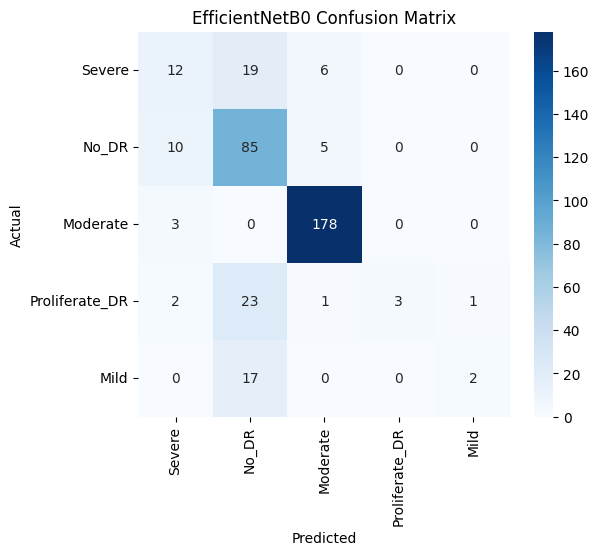

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

# 📊 11. Classification Report
Compute:

- Precision
- Recall
- F1-score

for each class.

In [22]:
eff_test_gen.reset()
pred = eff_model.predict(eff_test_gen)
pred = np.argmax(y_prob, axis=1)

print(classification_report(
    eff_test_gen.classes,
    pred,
    target_names=class_names
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
                precision    recall  f1-score   support

        Severe       0.44      0.32      0.38        37
         No_DR       0.59      0.85      0.70       100
      Moderate       0.94      0.98      0.96       181
Proliferate_DR       1.00      0.10      0.18        30
          Mild       0.67      0.11      0.18        19

      accuracy                           0.76       367
     macro avg       0.73      0.47      0.48       367
  weighted avg       0.78      0.76      0.73       367



# ⚖️ 12. Handling Class Imbalance Using Class Weights

The dataset contains an unequal number of images across diabetic retinopathy stages.

To reduce the bias toward majority classes, class weights are computed automatically using Scikit-learn.

During training, samples from minority classes contribute more to the loss function, encouraging the model to learn more balanced decision boundaries.

This technique aims to improve the recognition of underrepresented disease stages without modifying the dataset itself.

In [23]:
classes = np.unique(df_train["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_train["label"]
)

class_weights = dict(zip(classes, class_weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{'Mild': np.float64(1.9766666666666666), 'Moderate': np.float64(0.7330037082818294), 'No_DR': np.float64(0.405886379192334), 'Proliferate_DR': np.float64(2.491596638655462), 'Severe': np.float64(3.7770700636942673)}


In [24]:
base_model_cw = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=IMAGE_SHAPE
)

In [25]:
base_model_cw.trainable = False

x = base_model_cw.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(5, activation="softmax")(x)

eff_model_cw = Model(
    inputs=base_model_cw.input,
    outputs=output
)

In [26]:
eff_model_cw.compile(
    optimizer=Adam(1e-4),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

In [27]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-5
)

checkpoint = ModelCheckpoint(
    "EfficientNetB0_best_DR_cw.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [28]:
eff_history_cw = eff_model_cw.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 83s 681ms/step - accuracy: 0.6550 - loss: 0.9671 - val_accuracy: 0.6606 - val_loss: 0.8484 - learning_rate: 1.0000e-04
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 465ms/step - accuracy: 0.7315 - loss: 0.7408 - val_accuracy: 0.7303 - val_loss: 0.7335 - learning_rate: 1.0000e-04
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 467ms/step - accuracy: 0.7514 - loss: 0.6773 - val_accuracy: 0.7485 - val_loss: 0.6940 - learning_rate: 1.0000e-04
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 42s 453ms/step - accuracy: 0.7690 - loss: 0.6314 - val_accuracy: 0.7606 - val_loss: 0.6836 - learning_rate: 1.0000e-04
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 42s 456ms/step - accuracy: 0.7788 - loss: 0.6118 - val_accuracy: 0.7606 - val_loss: 0.6552 - learning_rate: 1.0000e-04
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 463ms/step - accuracy: 0.7852 - loss: 0.5817 - val_accuracy: 0.7667 - val_loss: 0.6450 - learning_rate: 1.0000e-04
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 462ms/step - acc

In [29]:
base_model_cw.trainable = True
for layer in base_model_cw.layers[:-30]:
    layer.trainable = False

eff_model_cw.compile(
    optimizer=Adam(1e-5),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

eff_history_finetune_cw = eff_model_cw.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,    
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 95s 729ms/step - accuracy: 0.7099 - loss: 0.8059 - val_accuracy: 0.7727 - val_loss: 0.6307 - learning_rate: 1.0000e-05
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 474ms/step - accuracy: 0.7548 - loss: 0.6825 - val_accuracy: 0.7515 - val_loss: 0.6262 - learning_rate: 1.0000e-05
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 472ms/step - accuracy: 0.7713 - loss: 0.6368 - val_accuracy: 0.7576 - val_loss: 0.6135 - learning_rate: 1.0000e-05
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 468ms/step - accuracy: 0.7811 - loss: 0.6131 - val_accuracy: 0.7606 - val_loss: 0.6071 - learning_rate: 1.0000e-05
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 469ms/step - accuracy: 0.7828 - loss: 0.5965 - val_accuracy: 0.7576 - val_loss: 0.6023 - learning_rate: 1.0000e-05
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 465ms/step - accuracy: 0.7899 - loss: 0.5790 - val_accuracy: 0.7667 - val_loss: 0.5984 - learning_rate: 1.0000e-05
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 462ms/step - acc

# 📈 13. Model Evaluation

The trained model is evaluated using the unseen testing dataset.

Several evaluation metrics are reported, including:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

Since the dataset is imbalanced, macro-averaged metrics are analyzed in addition to overall accuracy to better evaluate the model's performance across all diabetic retinopathy stages.

In [30]:
print("Train class evaluate :", eff_model_cw.evaluate(eff_train_gen))
print("Val class evaluate :", eff_model_cw.evaluate(eff_val_gen))
print("Test class evaluate :", eff_model_cw.evaluate(eff_test_gen))

93/93 ━━━━━━━━━━━━━━━━━━━━ 47s 508ms/step - accuracy: 0.8347 - loss: 0.4450
Train class evaluate : [0.4449639618396759, 0.8347386121749878]
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.7879 - loss: 0.5714 
Val class evaluate : [0.5713889002799988, 0.7878788113594055]
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 538ms/step - accuracy: 0.7602 - loss: 0.5895
Test class evaluate : [0.5894792675971985, 0.7602179646492004]


In [31]:
eff_test_gen.reset()

y_prob = eff_model_cw.predict(eff_test_gen)
y_pred = np.argmax(y_prob, axis=1)

y_true = eff_test_gen.classes

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 677ms/step


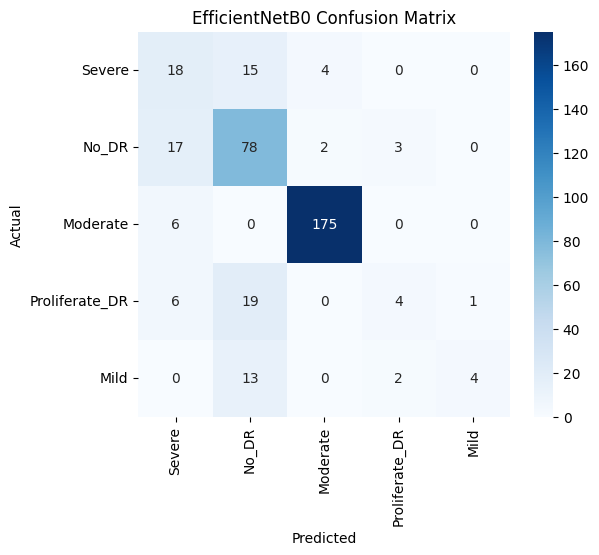

In [32]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

In [33]:
eff_test_gen.reset()
pred = eff_model_cw.predict(eff_test_gen)
pred = np.argmax(y_prob, axis=1)

print(classification_report(
    eff_test_gen.classes,
    pred,
    target_names=class_names
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
                precision    recall  f1-score   support

        Severe       0.38      0.49      0.43        37
         No_DR       0.62      0.78      0.69       100
      Moderate       0.97      0.97      0.97       181
Proliferate_DR       0.44      0.13      0.21        30
          Mild       0.80      0.21      0.33        19

      accuracy                           0.76       367
     macro avg       0.64      0.52      0.53       367
  weighted avg       0.76      0.76      0.74       367



# 🔥 14. Improving Minority Class Detection Using Focal Loss

Although class weighting helps reduce class imbalance, difficult minority samples may still receive insufficient attention.

To address this issue, the standard categorical cross-entropy loss is replaced with **Categorical Focal Loss**.

Focal Loss reduces the contribution of easily classified samples while emphasizing difficult examples, allowing the model to focus on challenging diabetic retinopathy stages.

This strategy is particularly effective for highly imbalanced medical image classification tasks.

In [34]:
base_model_focal = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=IMAGE_SHAPE
)

In [35]:
base_model_focal.trainable = False

x = base_model_focal.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(5, activation="softmax")(x)

eff_model_focal = Model(
    inputs=base_model_focal.input,
    outputs=output
)

In [36]:
eff_model_focal.compile(
    optimizer=Adam(1e-4),
    loss=CategoricalFocalCrossentropy(
        gamma=2.0
    ),
    metrics=[METRICS]
)

In [37]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-5
)

checkpoint = ModelCheckpoint(
    "EfficientNetB0_best_DR_cw_focal.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [38]:
eff_history_focal = eff_model_focal.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 86s 707ms/step - accuracy: 0.5835 - loss: 0.2007 - val_accuracy: 0.5909 - val_loss: 0.1721 - learning_rate: 1.0000e-04
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 45s 482ms/step - accuracy: 0.6924 - loss: 0.1304 - val_accuracy: 0.7545 - val_loss: 0.1026 - learning_rate: 1.0000e-04
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 467ms/step - accuracy: 0.7207 - loss: 0.1156 - val_accuracy: 0.7515 - val_loss: 0.0922 - learning_rate: 1.0000e-04
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 469ms/step - accuracy: 0.7312 - loss: 0.1072 - val_accuracy: 0.7515 - val_loss: 0.0884 - learning_rate: 1.0000e-04
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 471ms/step - accuracy: 0.7450 - loss: 0.1020 - val_accuracy: 0.7212 - val_loss: 0.0896 - learning_rate: 1.0000e-04
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 471ms/step - accuracy: 0.7629 - loss: 0.0923 - val_accuracy: 0.7394 - val_loss: 0.0907 - learning_rate: 1.0000e-04
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 469ms/step - acc

In [39]:
base_model_focal.trainable = True
for layer in base_model_focal.layers[:-30]:
    layer.trainable = False

eff_model_focal.compile(
    optimizer=Adam(1e-5),
    loss=CategoricalFocalCrossentropy(
        gamma=2.0
    ),
    metrics=[METRICS]
)

eff_history_finetune_focal = eff_model_focal.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,    
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 95s 731ms/step - accuracy: 0.5683 - loss: 0.2083 - val_accuracy: 0.7242 - val_loss: 0.1029 - learning_rate: 1.0000e-05
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 474ms/step - accuracy: 0.6223 - loss: 0.1883 - val_accuracy: 0.7273 - val_loss: 0.1179 - learning_rate: 1.0000e-05
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 467ms/step - accuracy: 0.6509 - loss: 0.1677 - val_accuracy: 0.7273 - val_loss: 0.1287 - learning_rate: 1.0000e-05
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 461ms/step - accuracy: 0.6597 - loss: 0.1621 - val_accuracy: 0.7152 - val_loss: 0.1307 - learning_rate: 1.0000e-05
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 464ms/step - accuracy: 0.6931 - loss: 0.1412 - val_accuracy: 0.7152 - val_loss: 0.1290 - learning_rate: 1.0000e-05


# 📈 15. Model Evaluation

The trained model is evaluated using the unseen testing dataset.

Several evaluation metrics are reported, including:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

Since the dataset is imbalanced, macro-averaged metrics are analyzed in addition to overall accuracy to better evaluate the model's performance across all diabetic retinopathy stages.

In [40]:
print("Train class evaluate :", eff_model_focal.evaluate(eff_train_gen))
print("Val class evaluate :", eff_model_focal.evaluate(eff_val_gen))
print("Test class evaluate :", eff_model_focal.evaluate(eff_test_gen))

93/93 ━━━━━━━━━━━━━━━━━━━━ 48s 510ms/step - accuracy: 0.7690 - loss: 0.0815
Train class evaluate : [0.08147165924310684, 0.76897132396698]
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.7242 - loss: 0.1029
Val class evaluate : [0.10293222218751907, 0.7242424488067627]
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 546ms/step - accuracy: 0.6975 - loss: 0.1077
Test class evaluate : [0.10774505138397217, 0.6975476741790771]


In [41]:
eff_test_gen.reset()

y_prob = eff_model_focal.predict(eff_test_gen)
y_pred = np.argmax(y_prob, axis=1)

y_true = eff_test_gen.classes

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 679ms/step


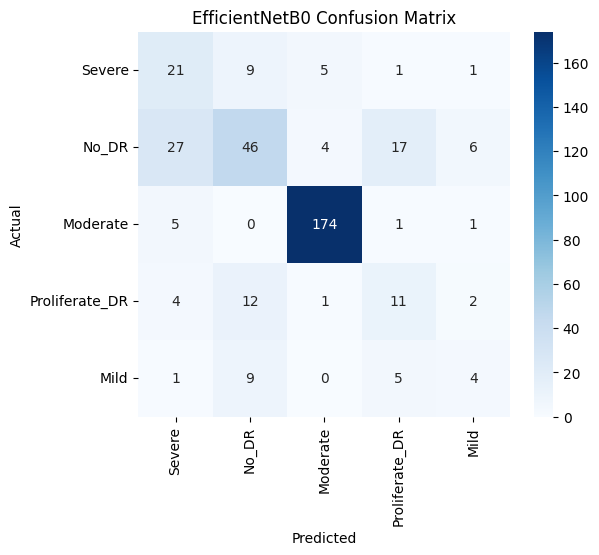

In [42]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

In [43]:
eff_test_gen.reset()
pred = eff_model_focal.predict(eff_test_gen)
pred = np.argmax(y_prob, axis=1)

print(classification_report(
    eff_test_gen.classes,
    pred,
    target_names=class_names
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
                precision    recall  f1-score   support

        Severe       0.36      0.57      0.44        37
         No_DR       0.61      0.46      0.52       100
      Moderate       0.95      0.96      0.95       181
Proliferate_DR       0.31      0.37      0.34        30
          Mild       0.29      0.21      0.24        19

      accuracy                           0.70       367
     macro avg       0.50      0.51      0.50       367
  weighted avg       0.71      0.70      0.70       367



# 📌 16. Summary of Optimization Techniques

To systematically improve the EfficientNetB0 model, several optimization strategies were evaluated.

### ✔ Baseline Model
- EfficientNetB0 pretrained on ImageNet.
- Transfer learning with frozen backbone.

### ✔ Fine-Tuning
- Unfroze the last layers of EfficientNetB0.
- Adapted high-level features to retinal images.

### ✔ Class Weighting
- Addressed class imbalance by assigning higher importance to minority classes during training.

### ✔ Strong Data Augmentation
- Increased image diversity through geometric transformations to improve generalization.

### ✔ Focal Loss
- Replaced categorical cross-entropy with focal loss to improve learning from difficult and minority-class samples.

Each technique was evaluated independently to ensure a fair comparison and identify its individual contribution to the final model performance.